# Hölder's Inequality

## Statement

**Hölder's inequality** is one of the most fundamental inequalities in analysis. For conjugate exponents $p, q \geq 1$ satisfying $\frac{1}{p} + \frac{1}{q} = 1$, and for vectors $u, v \in \mathbb{R}^n$:

$$\langle u, v \rangle = \sum_{i=1}^n u_i v_i \leq \|u\|_p \|v\|_q$$

where $\|u\|_p = \left(\sum_i |u_i|^p\right)^{1/p}$. The **Cauchy–Schwarz inequality** is the special case $p = q = 2$.

## The Geometric Picture

The Hölder inequality can be restated as:
$$\frac{\langle u, v \rangle}{\|u\|_p \|v\|_q} \leq 1$$

Defining the **defect**:
$$\delta_p(u, v) = 1 - \frac{\langle u, v \rangle}{\|u\|_p \|v\|_q} \geq 0$$

equality holds if and only if $|u_i|^p / \|u\|_p^p = |v_i|^q / \|v\|_q^q$ for all $i$, i.e., when $u$ and $v$ are **Hölder duals** of each other.

## 2D Visualization

In 2D, we fix a direction $v = (\cos\theta, \sin\theta)$ and plot the function:
$$U_p(x) = 1 - \frac{\langle x, v \rangle}{\|x\|_p \|v\|_q}$$

over the unit square. The level sets of $U_p$ are ellipse-like curves that reveal the geometry of the $L^p$–$L^q$ dual pairing.

### Environment setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

### $L^p$ norms and Hölder conjugates

For $p \geq 1$, the $L^p$ norm of a 2D vector $(x, y)$ is:
$$\|(x,y)\|_p = (|x|^p + |y|^p)^{1/p}$$

The **Hölder conjugate** satisfies $1/p + 1/q = 1$, i.e., $q = p/(p-1)$. As $p \to 1$, $q \to \infty$; as $p \to \infty$, $q \to 1$; at $p=2$, $q=2$.

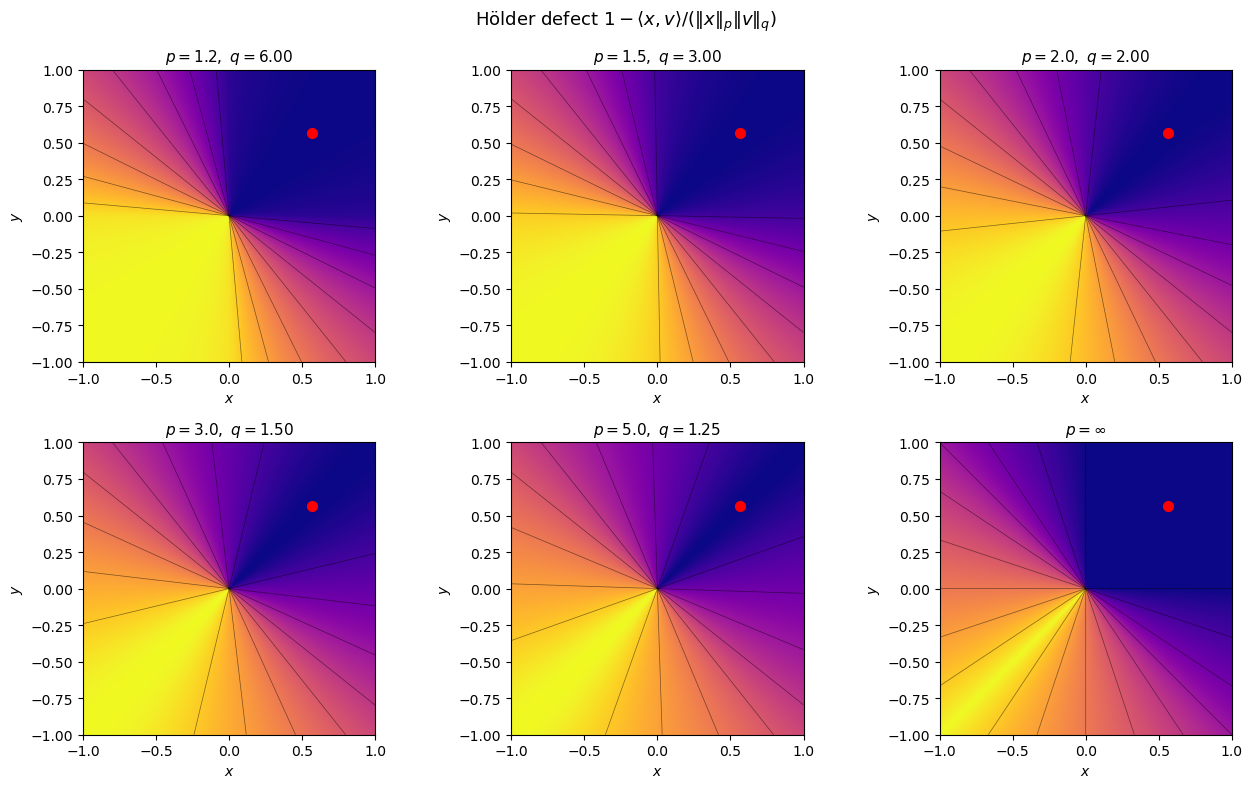

In [2]:
n = 400
x_grid = np.linspace(-1, 1, n)
y_grid = np.linspace(-1, 1, n)
Y, X = np.meshgrid(y_grid, x_grid)

def lp_norm(x, y, p):
    return (np.abs(x)**p + np.abs(y)**p)**(1.0/p)

def holder_defect(X, Y, v0, v1, p):
    q = p / (p - 1)
    dot = X * v0 + Y * v1
    norm_x = lp_norm(X, Y, p)
    norm_v = lp_norm(v0, v1, q)
    with np.errstate(divide='ignore', invalid='ignore'):
        U = 1.0 - dot / (norm_x * norm_v + 1e-12)
    return U

# Visualize for several p values with a fixed direction v
p_values = [1.2, 1.5, 2.0, 3.0, 5.0, np.inf]
theta = np.pi / 4
v0, v1 = np.cos(theta), np.sin(theta)

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.ravel()
for ax, p in zip(axes, p_values):
    if np.isinf(p):
        norm_x = np.maximum(np.abs(X), np.abs(Y))
        norm_v = max(abs(v0), abs(v1))
        U = 1.0 - (X*v0 + Y*v1) / (norm_x * norm_v + 1e-12)
        label = r'$p=\infty$'
    else:
        U = holder_defect(X, Y, v0, v1, p)
        q = p / (p - 1)
        label = fr'$p={p:.1f},\ q={q:.2f}$'
    U = U / np.nanmax(U[np.isfinite(U)])
    im = ax.imshow(U.T, extent=[-1,1,-1,1], origin='lower', cmap='parula' if False else 'plasma',
                   vmin=0, vmax=1)
    ax.contour(X, Y, U, levels=np.linspace(0,1,10), colors='k', linewidths=0.5, alpha=0.5)
    ax.plot(v0*0.8, v1*0.8, 'r.', markersize=14)
    ax.set_title(label, fontsize=11); ax.set_aspect('equal')
    ax.set_xlabel('$x$'); ax.set_ylabel('$y$')

plt.suptitle("Hölder defect $1 - \\langle x,v \\rangle / (\\|x\\|_p\\|v\\|_q)$", fontsize=13)
plt.tight_layout()
plt.savefig('holder_defect.png', dpi=100, bbox_inches='tight')
plt.show()

### $L^p$ unit balls and their duals

The unit ball $B_p = \{x : \|x\|_p \leq 1\}$ is a convex body. Its **polar dual** is $B_p^\circ = B_q$, the unit $L^q$ ball. This duality is precisely what Hölder's inequality encodes: for $x \in B_p$ and $y \in B_q$,
$$|\langle x, y \rangle| \leq 1$$

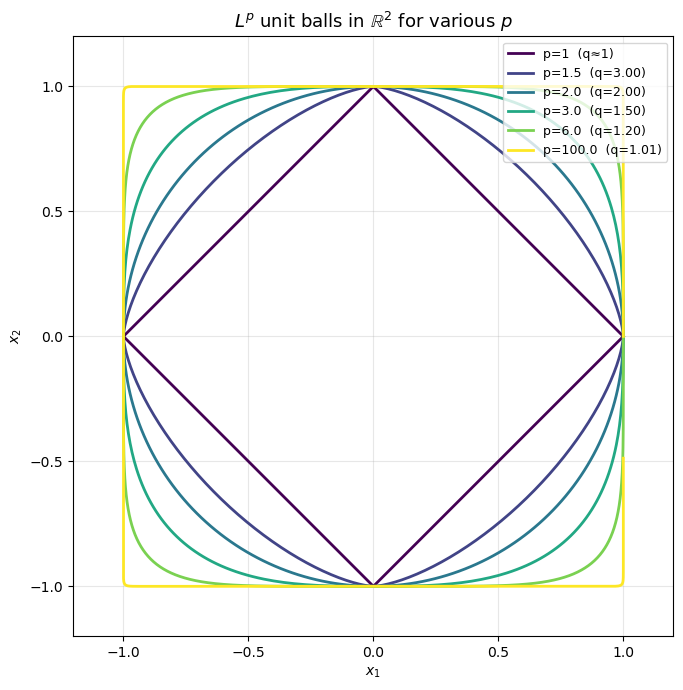

In [3]:
t = np.linspace(0, 2*np.pi, 500)
p_vals = [1.0, 1.5, 2.0, 3.0, 6.0, 100.0]

fig, ax = plt.subplots(figsize=(7, 7))
colors = plt.cm.viridis(np.linspace(0, 1, len(p_vals)))

for p, col in zip(p_vals, colors):
    # Parametric boundary of Lp unit ball
    x_b = np.sign(np.cos(t)) * np.abs(np.cos(t))**(2/p)
    y_b = np.sign(np.sin(t)) * np.abs(np.sin(t))**(2/p)
    q = p / (p - 1) if p > 1 else np.inf
    lbl = f'p={p:.1f}  (q={q:.2f})' if q < 100 else f'p={p:.0f}  (q≈1)'
    ax.plot(x_b, y_b, color=col, lw=2, label=lbl)

ax.set_aspect('equal'); ax.set_xlim(-1.2, 1.2); ax.set_ylim(-1.2, 1.2)
ax.legend(fontsize=9, loc='upper right')
ax.set_title(r'$L^p$ unit balls in $\mathbb{R}^2$ for various $p$', fontsize=13)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('unit_balls.png', dpi=100, bbox_inches='tight')
plt.show()

### Interactive: Hölder defect with rotating direction

The slider controls $\theta$ (the direction of $v$) and $p$. The red dot marks the Hölder dual of $v$, which achieves equality.

In [ ]:
def plot_holder(p=2.0, theta_deg=45.0):
    theta = np.radians(theta_deg)
    v0, v1 = np.cos(theta), np.sin(theta)
    if p <= 1.01:
        p = 1.01
    U = holder_defect(X, Y, v0, v1, p)
    U = U / np.nanmax(U[np.isfinite(U)])
    q = p / (p - 1)
    # Hölder dual of v: sign(v_i) * |v_i|^(q-1) / ||v||_q^(q-1)
    dual = np.sign([v0,v1]) * np.abs([v0,v1])**(q-1)
    dual = dual / (lp_norm(v0,v1,q) + 1e-12) * 0.85

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(U.T, extent=[-1,1,-1,1], origin='lower', cmap='plasma', vmin=0, vmax=1)
    ax.contour(X, Y, U, levels=12, colors='k', linewidths=0.5, alpha=0.6)
    ax.plot(v0*0.85, v1*0.85, 'r.', markersize=18, label='$v$')
    ax.plot(dual[0], dual[1], 'c*', markersize=14, label='Hölder dual of $v$')
    ax.set_title(f'Hölder defect, $p={p:.2f}$, $q={q:.2f}$, $\\theta={theta_deg:.0f}°$')
    ax.legend(fontsize=9); ax.set_aspect('equal')
    plt.tight_layout(); plt.show()

interact(plot_holder,
         p=FloatSlider(min=1.05, max=8.0, step=0.05, value=2.0, description='p'),
         theta_deg=FloatSlider(min=0, max=360, step=5, value=45, description='θ (°)'));

### Snippet

In [4]:
STATIC_SNAPSHOT = True
if STATIC_SNAPSHOT:
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as _plt

    fig, axes = _plt.subplots(2, 3, figsize=(10, 7))
    axes = axes.ravel()
    for ax, p in zip(axes, [1.2, 1.5, 2.0, 3.0, 5.0, 20.0]):
        theta = np.pi * 0.35
        v0t, v1t = np.cos(theta), np.sin(theta)
        if p < 1.1: p = 1.1
        U = holder_defect(X, Y, v0t, v1t, p)
        U = U / (np.nanmax(U[np.isfinite(U)]) + 1e-12)
        q = p / (p - 1)
        ax.imshow(U.T, extent=[-1,1,-1,1], origin='lower', cmap='plasma', vmin=0, vmax=1)
        ax.contour(X, Y, U, levels=10, colors='k', linewidths=0.4, alpha=0.5)
        ax.plot(v0t*0.85, v1t*0.85, 'r.', markersize=12)
        ax.set_title(f'p={p:.1f}, q={q:.2f}', fontsize=10)
        ax.set_aspect('equal'); ax.axis('off')
    fig.tight_layout()
    fig.savefig('snippet.png', dpi=150, bbox_inches='tight')

## Takeaways

- Hölder's inequality $\langle u,v\rangle \leq \|u\|_p \|v\|_q$ holds for all conjugate pairs $(p,q)$ with $1/p + 1/q = 1$.
- The **$L^p$ unit ball** and the **$L^q$ unit ball** are polar duals, capturing the same geometric content.
- Equality holds iff $|u_i|^{p-1} \propto |v_i|$ with matching signs — the **Hölder dual** condition.
- As $p \to 1$, the inequality becomes the $L^1$–$L^\infty$ bound; as $p \to \infty$, it becomes $L^\infty$–$L^1$.

## Bibliography

- O. Hölder, *Über einen Mittelwerthsatz*, Göttinger Nachrichten, 1889.
- W. Rudin, *Real and Complex Analysis*, McGraw-Hill, 1987.
- R. T. Rockafellar, *Convex Analysis*, Princeton UP, 1970.